# 1. Import dependancies

In [ ]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,balanced_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import metrics
from mlxtend.plotting import plot_confusion_matrix

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense
from sklearn.utils import class_weight
from keras.models import Sequential, load_model
from tensorflow.keras import datasets, layers, models

#2. Import data

In [ ]:
PY = False
if not PY:
    from google.colab import drive
    import os
    drive.mount('/content/drive')
    road_accidents_df = pd.read_csv('/content/drive/MyDrive/MSc Greenwich/Applied Machine Learning/coursework/OPTION1_uk_road_accident_2019_coursework_final.csv')
else:
    road_accidents_df = pd.read_csv('OPTION1_uk_road_accident_2019_coursework_final.csv.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#3. Functions

In [ ]:
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
from IPython.display import HTML
def pretty_print_df(value_counts_):
  display(HTML(pd.DataFrame(value_counts_).to_html()))

In [ ]:
def analyse(df,Target, categorical_columns):
  head = df.head(3)
  features = df.columns
  shape = df.shape
  des = df.describe
  datatype = df.dtypes
  dups_ = df.duplicated(keep='last')
  null_count = df.isna().sum()
  data_imbalance = df[Target].value_counts()
  for col in categorical_columns:
    pretty_print_df(df[col].value_counts())
  return head, features, shape, des, datatype, null_count, data_imbalance, dups_

# 4. Exploratory Data Analysis

In [ ]:
head, features, shape, des, datatype, null_count, data_imbalance, duplicates = analyse(road_accidents_df, 'accident_severity',['light_conditions',
       'weather_conditions', 'road_surface_conditions', 'vehicle_type',
       'junction_location', 'skidding_and_overturning',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
       'first_point_of_impact', 'sex_of_driver',
       'accident_severity'])

,light_conditions
daylight,22210
darkness,9437


,weather_conditions
fine,25152
other,5407
data missing or out of range,970
fog or mist,118


,road_surface_conditions
dry,22092
wet or damp,8761
other,374
data missing or out of range,365
flood over 3cm. deep,55


,vehicle_type
only cars,17487
at least one biped,8662
at least one van,4040
biped and van,1000
other,395
data missing or out of range,63


,junction_location
at or within 20 metres of junction,17204
not at or within 20 metres of junction,12973
data missing or out of range,1470


...

,vehicle_leaving_carriageway
none leaving carriageway,24019
at least one vehicle leaving carriageway,5661
data missing or out of range,1967


,hit_object_off_carriageway
none hit an object,26129
at least one vehicle hit an object,3655
data missing or out of range,1863


,first_point_of_impact
at least one vehicle with frontal impact,23002
other points of impact,6008
no impact,1333
data missing or out of range,1304


,sex_of_driver
all males,15494
male and female,7015
data missing or out of range,5122
all females,4016


,accident_severity
slight,12672
serious,11592
fatal,6159
Serious,25
Slight,19
Fatal,8


In [ ]:
print(color.BOLD + "UK road accident 2019 dataset: \n")
head

UK road accident 2019 dataset: 



,accident_index,speed_limit,light_conditions,weather_conditions,road_surface_conditions,vehicle_type,junction_location,skidding_and_overturning,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,sex_of_driver,age_of_oldest_driver,accident_severity
0,2019010225080,30,darkness,other,wet or damp,at least one van,at or within 20 metres of junction,no skidding or overturning,none leaving carriageway,none hit an object,other points of impact,all males,63.0,serious
1,2019200908684,30,darkness,fine,dry,only cars,at or within 20 metres of junction,no skidding or overturning,at least one vehicle leaving carriageway,at least one vehicle hit an object,at least one vehicle with frontal impact,all males,82.0,fatal
2,2019040860897,40,daylight,fine,dry,only cars,at or within 20 metres of junction,no skidding or overturning,none leaving carriageway,none hit an object,at least one vehicle with frontal impact,data missing or out of range,NaN,serious


In [ ]:
print(color.BOLD + "UK road accident 2019 shape of the dataset: \n")
shape

UK road accident 2019 shape of the dataset: 



(31647, 14)

In [ ]:
print(color.BOLD + "Feature list: \n")
features[0:-1].to_list()

Feature list: 



['accident_index',
 'speed_limit',
 'light_conditions',
 'weather_conditions',
 'road_surface_conditions',
 'vehicle_type',
 'junction_location',
 'skidding_and_overturning',
 'vehicle_leaving_carriageway',
 'hit_object_off_carriageway',
 'first_point_of_impact',
 'sex_of_driver',
 'age_of_oldest_driver']

In [ ]:
print(color.BOLD + "Column data types: \n")
datatype

Column data types: 



accident_index                  object
speed_limit                      int64
light_conditions                object
weather_conditions              object
road_surface_conditions         object
vehicle_type                    object
junction_location               object
skidding_and_overturning        object
vehicle_leaving_carriageway     object
hit_object_off_carriageway      object
first_point_of_impact           object
sex_of_driver                   object
age_of_oldest_driver           float64
accident_severity               object
dtype: object

In [ ]:
print(color.BOLD +"Dataframe null value count: \n")
null_count

Dataframe null value count: 



accident_index                    0
speed_limit                       0
light_conditions                  0
weather_conditions                0
road_surface_conditions           0
vehicle_type                      0
junction_location                 0
skidding_and_overturning          0
vehicle_leaving_carriageway       0
hit_object_off_carriageway        0
first_point_of_impact             0
sex_of_driver                     0
age_of_oldest_driver           6450
accident_severity              1172
dtype: int64

In [ ]:
print(color.BOLD + "Target variable: \n", features[-1])

Target variable: 
 accident_severity


# 5. Data Preprocessing

### 5.1 Handling duplicate records

In [ ]:
print(color.BOLD + "Number of distint values in accident_index: ", len(road_accidents_df['accident_index'].unique()))

Number of distint values in accident_index:  30475


In [ ]:
print(color.BOLD + "Number of records in the dataframe; {}\nNumber of duplicate records: {}".format(shape[0],duplicates.sum()))

Number of records in the dataframe; 31647
Number of duplicate records: 1172


In [ ]:
road_accidents_df = road_accidents_df.drop_duplicates(subset=['accident_index'])

In [ ]:
road_accidents_df.shape

(30475, 14)

**`Since the duplicates are removed. 'accident_index' can be set as the index as it contains distinct values.`**

In [ ]:
road_accidents_df = road_accidents_df.set_index('accident_index')

### 5.2 Handling redundancy categories

In [ ]:
road_accidents_df['accident_severity'].value_counts()

slight     12171
serious    11156
fatal       5926
Serious       24
Slight        19
Fatal          7
Name: accident_severity, dtype: int64

In [ ]:
road_accidents_df.loc[road_accidents_df.accident_severity=='serious','accident_severity'] = 'Serious'
road_accidents_df.loc[road_accidents_df.accident_severity=='slight','accident_severity'] = 'Slight'
road_accidents_df.loc[road_accidents_df.accident_severity=='fatal','accident_severity'] = 'Fatal'

In [ ]:
road_accidents_df['accident_severity'].value_counts()

Slight     12190
Serious    11180
Fatal       5933
Name: accident_severity, dtype: int64

### 5.3 Rename the categories in the weather_conditions feature

In [ ]:
road_accidents_df.loc[road_accidents_df.weather_conditions=='fog or mist','weather_conditions'] = 'mist'

### 5.4 Rename the categories in the road_surface_conditions feature

In [ ]:
road_accidents_df.loc[road_accidents_df.road_surface_conditions=='wet or damp','road_surface_conditions'] = 'wet'

## 5.5 Analyse the impact of numerical features

### 5.5.1 Correlation of numerical features

In [ ]:
corr = road_accidents_df.corr()
corr.style.background_gradient(cmap='viridis', axis=None).set_precision(2)

,speed_limit,age_of_oldest_driver
speed_limit,1.00,0.04
age_of_oldest_driver,0.04,1.00


### 5.5.2 Analysing the feature speed_limit

<Axes: xlabel='accident_severity', ylabel='speed_limit'>

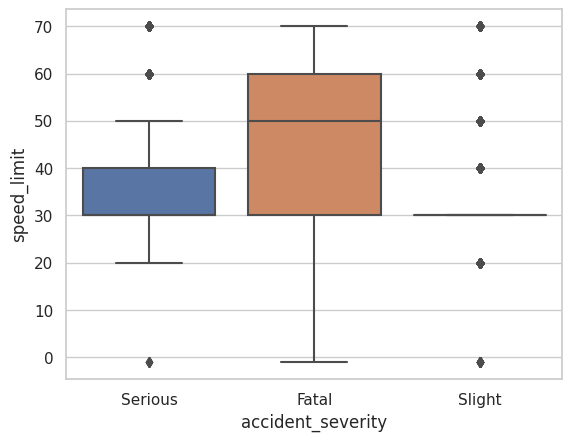

In [ ]:
plt.figure()
sns.boxplot(y=road_accidents_df['speed_limit'], x= road_accidents_df['accident_severity'])

In [ ]:
# Average speed limit based on the accident severity
road_accidents_df.groupby('accident_severity').speed_limit.mean().round(1)

accident_severity
Fatal      47.3
Serious    35.7
Slight     32.2
Name: speed_limit, dtype: float64

### 5.5.3 Analysing the feature age_of_oldest_driver

In [ ]:
road_accidents_df['age_of_oldest_driver'] = road_accidents_df['age_of_oldest_driver'].apply(lambda x: round(x,1) if not pd.isna(x) else None)

<Axes: xlabel='accident_severity', ylabel='age_of_oldest_driver'>

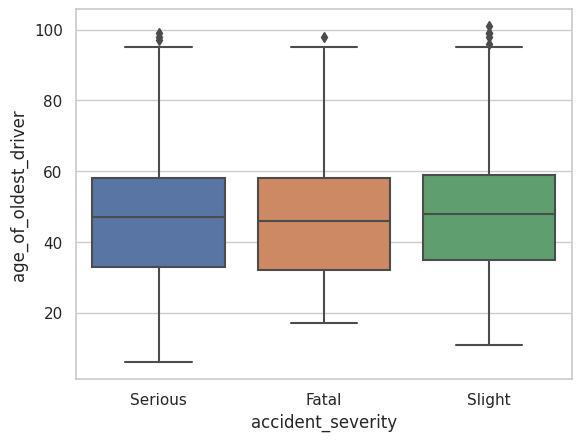

In [ ]:
plt.figure()
sns.boxplot(y=road_accidents_df['age_of_oldest_driver'], x= road_accidents_df['accident_severity'])

In [ ]:
# Average age_of_oldest_driver based on the accident severity
road_accidents_df.groupby('accident_severity').age_of_oldest_driver.mean().round(1)

accident_severity
Fatal      46.1
Serious    46.9
Slight     48.4
Name: age_of_oldest_driver, dtype: float64

### 5.5.4 Data distribution of the features 'age_of_oldest_driver' and 'speed_limit'

<Axes: >

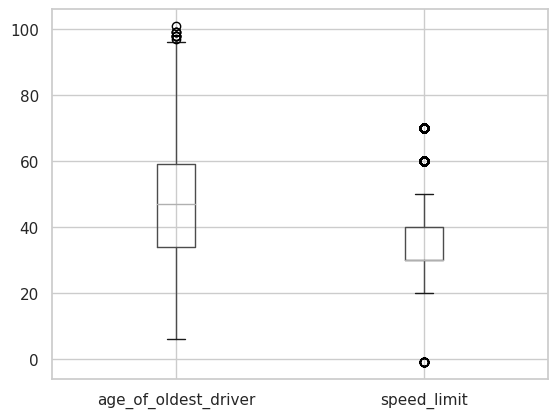

In [ ]:
road_accidents_df.boxplot(column=['age_of_oldest_driver', 'speed_limit'])

### 5.5.5 Reset the inconsistent values by setting a data limit

In [ ]:
road_accidents_df[['age_of_oldest_driver','speed_limit']].describe()

,age_of_oldest_driver,speed_limit
count,24240.000000,30475.000000
mean,47.274299,36.587564
std,16.793081,13.852336
min,6.000000,-1.000000
25%,34.000000,30.000000
50%,47.000000,30.000000
75%,59.000000,40.000000
max,101.000000,70.000000


In [ ]:
# accepted age limit is 16
min_age = 16
filtered_df = road_accidents_df[road_accidents_df['age_of_oldest_driver']>=min_age].copy()

In [ ]:
print(color.BOLD + "Number of records that have age limit less than 16 for the feature 'age_of_oldest_driver': ", road_accidents_df.shape[0]-filtered_df.shape[0])

Number of records that have age limit less than 16 for the feature 'age_of_oldest_driver':  6255


In [ ]:
road_accidents_df.loc[road_accidents_df.age_of_oldest_driver<min_age,'age_of_oldest_driver'] = np.nan

In [ ]:
min_speed = 0
filtered_df1 = road_accidents_df[road_accidents_df['speed_limit']>=min_speed].copy()

In [ ]:
print(color.BOLD + "Number of inconsistent recods that are removed: ", road_accidents_df.shape[0]-filtered_df1.shape[0])

Number of inconsistent recods that are removed:  24


In [ ]:
road_accidents_df.loc[road_accidents_df.speed_limit<min_speed,'speed_limit'] = np.nan

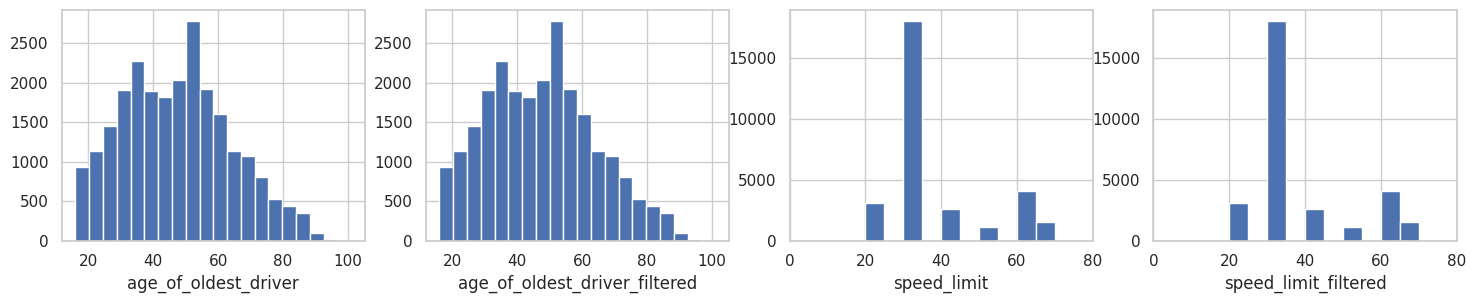

In [ ]:
_ = plt.figure(figsize=(18, 3))
ax3= plt.subplot(1,4,3)
_ = ax3.hist(road_accidents_df['speed_limit'], bins= 10)
_ = ax3.set_xlabel('speed_limit')
_ = ax3.set_xlim([0,80])

ax4 = plt.subplot(1,4,4)
_ = ax4.hist(filtered_df1['speed_limit'], bins= 10)
_ = ax4.set_xlabel('speed_limit_filtered')
_ = ax4.set_xlim([0,80])

ax1 = plt.subplot(1,4,1)
_ = ax1.hist(road_accidents_df['age_of_oldest_driver'], bins= 20)
_ = ax1.set_xlabel('age_of_oldest_driver')

ax2 = plt.subplot(1,4,2)
_ = ax2.hist(filtered_df['age_of_oldest_driver'], bins= 20)
_ = ax2.set_xlabel('age_of_oldest_driver_filtered')



### 5.6 Removing the null records of target accident_severity

**All the null records in the target are replaced with the string, 'null value'. Then remove that particular records.**

In [ ]:
road_accidents_df['accident_severity'] = road_accidents_df['accident_severity'].fillna(value='null value')

In [ ]:
road_accidents_df['accident_severity'].value_counts()

Slight        12190
Serious       11180
Fatal          5933
null value     1172
Name: accident_severity, dtype: int64

In [ ]:
target_null = road_accidents_df.loc[road_accidents_df['accident_severity'] == 'null value']
road_accidents_df_cleaned = road_accidents_df.loc[(road_accidents_df['accident_severity'] == 'Slight')  | (road_accidents_df['accident_severity'] == 'Serious') | (road_accidents_df['accident_severity'] == 'Fatal')]

# 6. Dataset split into train and validation

In [ ]:
X = road_accidents_df_cleaned.loc[:, road_accidents_df_cleaned.columns != 'accident_severity']
y = road_accidents_df_cleaned.loc[:, road_accidents_df_cleaned.columns == 'accident_severity']

In [ ]:
print(color.BOLD + "Size of the features : {}\nSize of the target : {} ".format(X.shape,y.shape))

Size of the features : (29303, 12)
Size of the target : (29303, 1) 


In [ ]:
train_holdout_ratio = 0.8
val_holdout_ratio = 0.1
test_holdout_ratio = 0.1

# 20% holdout
x_train_val, x_test, y_train_val, y_test = train_test_split(X, y, stratify=y, test_size = test_holdout_ratio)
print(color.BOLD + "Size of the test features : {}\nSize of test target : {} ".format(x_test.shape,y_test.shape))

x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, stratify=y_train_val, test_size = val_holdout_ratio)
print(color.BOLD + "Size of the train features : {}\nSize of train target : {} ".format(x_train.shape,y_train.shape))
print(color.BOLD + "Size of the validation features : {}\nSize of validation target : {} ".format(x_val.shape,y_val.shape))

Size of the test features : (2931, 12)
Size of test target : (2931, 1) 
Size of the train features : (23734, 12)
Size of train target : (23734, 1) 
Size of the validation features : (2638, 12)
Size of validation target : (2638, 1) 


In [ ]:
y_train['accident_severity'].value_counts()

Slight     9874
Serious    9055
Fatal      4805
Name: accident_severity, dtype: int64

# 7. Imputing missing data

In [ ]:
print(color.BOLD +"x_train null value count: \n")
x_train.isnull().sum()

x_train null value count: 



speed_limit                      14
light_conditions                  0
weather_conditions                0
road_surface_conditions           0
vehicle_type                      0
junction_location                 0
skidding_and_overturning          0
vehicle_leaving_carriageway       0
hit_object_off_carriageway        0
first_point_of_impact             0
sex_of_driver                     0
age_of_oldest_driver           4842
dtype: int64

In [ ]:
print(color.BOLD +"x_test null value count: \n")
x_test.isnull().sum()

x_test null value count: 



speed_limit                      4
light_conditions                 0
weather_conditions               0
road_surface_conditions          0
vehicle_type                     0
junction_location                0
skidding_and_overturning         0
vehicle_leaving_carriageway      0
hit_object_off_carriageway       0
first_point_of_impact            0
sex_of_driver                    0
age_of_oldest_driver           640
dtype: int64

In [ ]:
print(color.BOLD +"x_val null value count: \n")
x_val.isnull().sum()

x_val null value count: 



speed_limit                      5
light_conditions                 0
weather_conditions               0
road_surface_conditions          0
vehicle_type                     0
junction_location                0
skidding_and_overturning         0
vehicle_leaving_carriageway      0
hit_object_off_carriageway       0
first_point_of_impact            0
sex_of_driver                    0
age_of_oldest_driver           510
dtype: int64

## 7.1 Replace numerical missing values with mean

In [ ]:
x_train_no_nans =  x_train.copy()
x_test_no_nans =  x_test.copy()
x_val_no_nans =  x_val.copy()

#--Imputer to handle numerical data by replacing the missing value by mean
imptr_num = SimpleImputer(missing_values = np.nan, strategy = 'mean')
imptr_num = imptr_num.fit(x_train_no_nans[['age_of_oldest_driver', 'speed_limit']])
x_train_no_nans[['age_of_oldest_driver', 'speed_limit']] = \
  imptr_num.transform(x_train_no_nans[['age_of_oldest_driver', 'speed_limit']])

print(color.BOLD +"Mean of the 'age_of_oldest_driver': ", round(x_train_no_nans['age_of_oldest_driver'].mean(),2))
print(color.BOLD +"Mean of the 'speed_limit': ", round(x_train_no_nans['speed_limit'].mean(),2))

Mean of the 'age_of_oldest_driver':  47.3
Mean of the 'speed_limit':  36.62


In [ ]:
x_test_no_nans[['age_of_oldest_driver', 'speed_limit']] = imptr_num.transform(x_test_no_nans[['age_of_oldest_driver', 'speed_limit']])

In [ ]:
x_val_no_nans[['age_of_oldest_driver', 'speed_limit']] = imptr_num.transform(x_val_no_nans[['age_of_oldest_driver', 'speed_limit']])

## 7.2 Replace categorical missing values with mode

In [ ]:
categorical_columns = ['light_conditions', 'weather_conditions', 'road_surface_conditions',
                       'vehicle_type', 'junction_location', 'skidding_and_overturning',
                       'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
                       'first_point_of_impact', 'sex_of_driver']
imptr_cat = SimpleImputer(missing_values = 'data missing or out of range', strategy = 'most_frequent')
imptr_cat = imptr_cat.fit(x_train_no_nans[categorical_columns])
x_train_no_nans[categorical_columns] = \
  imptr_cat.transform(x_train_no_nans[categorical_columns])
x_train_no_nans.head(3)

,speed_limit,light_conditions,weather_conditions,road_surface_conditions,vehicle_type,junction_location,skidding_and_overturning,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,sex_of_driver,age_of_oldest_driver
accident_index,,,,,,,,,,,,
2019500811487,30.0,daylight,fine,dry,biped and van,at or within 20 metres of junction,no skidding or overturning,none leaving carriageway,none hit an object,at least one vehicle with frontal impact,male and female,29.0
2019320662669,60.0,daylight,fine,dry,only cars,at or within 20 metres of junction,no skidding or overturning,at least one vehicle leaving carriageway,none hit an object,at least one vehicle with frontal impact,male and female,60.0
2019010226749,30.0,darkness,fine,dry,only cars,at or within 20 metres of junction,no skidding or overturning,none leaving carriageway,none hit an object,at least one vehicle with frontal impact,all males,50.0


In [ ]:
x_test_no_nans[categorical_columns] = imptr_cat.transform(x_test_no_nans[categorical_columns])

In [ ]:
x_val_no_nans[categorical_columns] = imptr_cat.transform(x_val_no_nans[categorical_columns])

# 8. Change data types

In [ ]:
x_train_no_nans.dtypes

speed_limit                    float64
light_conditions                object
weather_conditions              object
road_surface_conditions         object
vehicle_type                    object
junction_location               object
skidding_and_overturning        object
vehicle_leaving_carriageway     object
hit_object_off_carriageway      object
first_point_of_impact           object
sex_of_driver                   object
age_of_oldest_driver           float64
dtype: object

In [ ]:
x_train_no_nans['age_of_oldest_driver'] = x_train_no_nans['age_of_oldest_driver'].astype(int)
x_test_no_nans['age_of_oldest_driver'] = x_test_no_nans['age_of_oldest_driver'].astype(int)
x_val_no_nans['age_of_oldest_driver'] = x_val_no_nans['age_of_oldest_driver'].astype(int)

In [ ]:
road_accidents_df.dtypes

speed_limit                    float64
light_conditions                object
weather_conditions              object
road_surface_conditions         object
vehicle_type                    object
junction_location               object
skidding_and_overturning        object
vehicle_leaving_carriageway     object
hit_object_off_carriageway      object
first_point_of_impact           object
sex_of_driver                   object
age_of_oldest_driver           float64
accident_severity               object
dtype: object

# 9. Class Imbalance

In [ ]:
sampleClassBias = y_train['accident_severity'].value_counts()
print('Training Labels distribution:')
pretty_print_df(sampleClassBias)

Training Labels distribution:


,accident_severity
Slight,9874
Serious,9055
Fatal,4805


<Axes: xlabel='accident_severity', ylabel='count'>

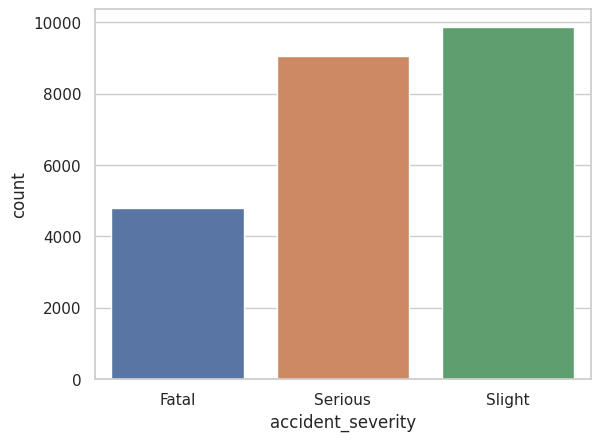

In [ ]:
sns.set_theme(style="whitegrid")
sns.countplot(x = y_train['accident_severity'])

# 10. Encoding categorical Data

In [ ]:
ct = ColumnTransformer(
    [
        (
            "onehot_categorical",
            OneHotEncoder(),
            categorical_columns,
        ),
    ],
    remainder="passthrough", #--> what to do with the non-transformed columns. passthrough=keep them
    verbose_feature_names_out=False #--> this keeps columns names simple. Try what happens if you set it as True
)

# create dataset copy for testing purposes
train_X_without_nan_encoded = x_train_no_nans.copy()
val_X_without_nan_encoded = x_val_no_nans.copy()
test_X_without_nan_encoded = x_test_no_nans.copy()

# the output is an numpy array with the encoded columns
encoded_array_train = ct.fit_transform(train_X_without_nan_encoded)
encoded_array_val = ct.transform(val_X_without_nan_encoded)
encoded_array_test= ct.transform(test_X_without_nan_encoded)

# What if we want a dataframe back? We can combine the array with the info about
# the original and transformed column names.
# This is stored in the ColumnTransformer object, which we called "ct"
# We can access it via the "get_feature_names_out()" attribute like this:
encoded_col_names= ct.get_feature_names_out() #remember python's dot notation
print(color.BOLD + "Total columns after encoding: {} \nAll column names in the dataset: \n{}".format(len(encoded_col_names),encoded_col_names))

train_X_without_nan_encoded = pd.DataFrame(encoded_array_train, columns=encoded_col_names)
val_X_without_nan_encoded = pd.DataFrame(encoded_array_val, columns=encoded_col_names)
test_X_without_nan_encoded = pd.DataFrame(encoded_array_test, columns=encoded_col_names)

Total columns after encoding: 30 
All column names in the dataset: 
['light_conditions_darkness' 'light_conditions_daylight'
 'weather_conditions_fine' 'weather_conditions_mist'
 'weather_conditions_other' 'road_surface_conditions_dry'
 'road_surface_conditions_flood over 3cm. deep'
 'road_surface_conditions_other' 'road_surface_conditions_wet'
 'vehicle_type_at least one biped' 'vehicle_type_at least one van'
 'vehicle_type_biped and van' 'vehicle_type_only cars'
 'vehicle_type_other'
 'junction_location_at or within 20 metres of junction'
 'junction_location_not at or within 20 metres of junction'
 'skidding_and_overturning_at least one vehicle skidded or overturned'
 'skidding_and_overturning_no skidding or overturning'
 'vehicle_leaving_carriageway_at least one vehicle leaving carriageway'
 'vehicle_leaving_carriageway_none leaving carriageway'
 'hit_object_off_carriageway_at least one vehicle hit an object'
 'hit_object_off_carriageway_none hit an object'
 'first_point_of_impact_a

# 11. Label encoding

In [ ]:
lblEncoder_X = LabelEncoder()
train_y_without_nan_encoded = lblEncoder_X.fit_transform(y_train)
val_y_without_nan_encoded = lblEncoder_X.transform(y_val)
test_y_without_nan_encoded = lblEncoder_X.transform(y_test)
train_y_without_nan_encoded

array([0, 1, 0, ..., 2, 2, 1])

# 12. Feature scaling

**OneHot encoded categorical variables and labels do not need to be scaled. The distributions of the input features can be plot using box plots.**

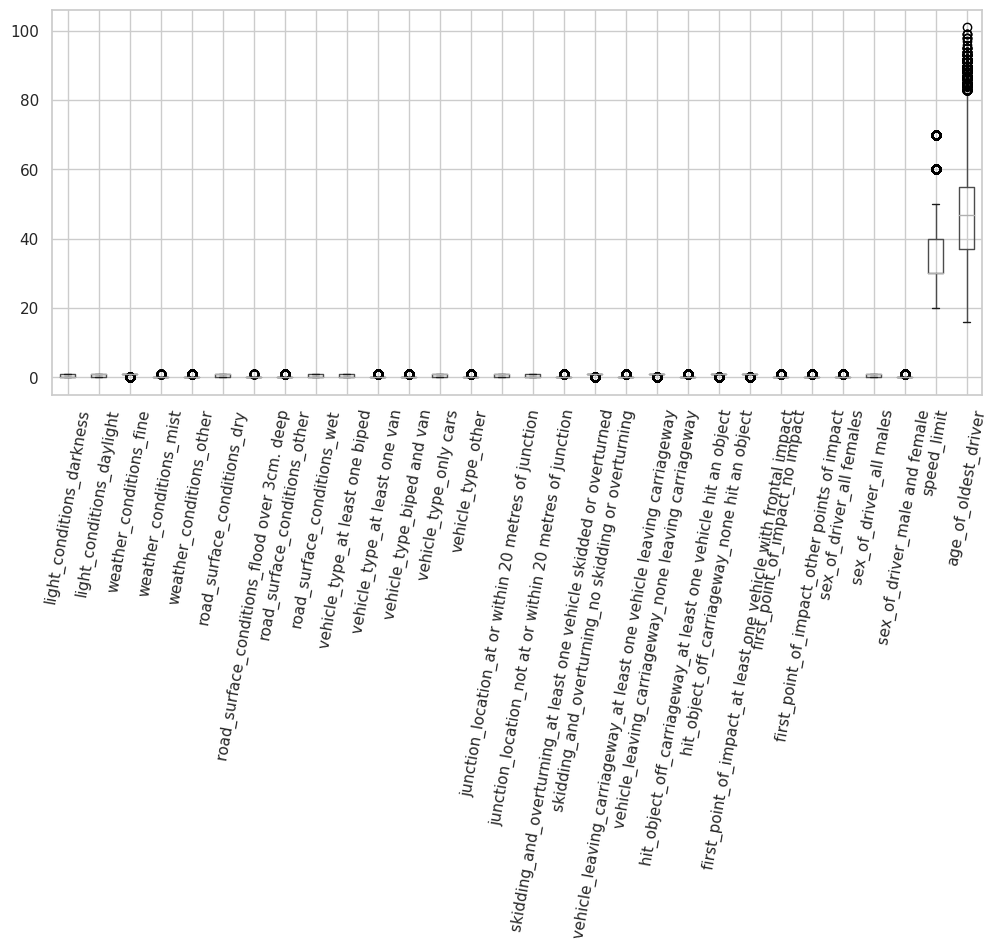

In [ ]:
fig=plt.figure(figsize=(12,5))
train_X_without_nan_encoded.boxplot()
_=plt.xticks(rotation=80)

In [ ]:
train_X_encoded_scaled = train_X_without_nan_encoded.copy()
val_X_encoded_scaled = val_X_without_nan_encoded.copy()
test_X_encoded_scaled = test_X_without_nan_encoded.copy()

scaler_num= StandardScaler().set_output(transform="pandas")
train_X_encoded_scaled[['speed_limit', 'age_of_oldest_driver']]=scaler_num.fit_transform(train_X_without_nan_encoded[['speed_limit', 'age_of_oldest_driver']])
val_X_encoded_scaled[['speed_limit', 'age_of_oldest_driver']]=scaler_num.transform(val_X_without_nan_encoded[['speed_limit', 'age_of_oldest_driver']])
test_X_encoded_scaled[['speed_limit', 'age_of_oldest_driver']]=scaler_num.transform(test_X_without_nan_encoded[['speed_limit', 'age_of_oldest_driver']])
train_X_encoded_scaled[['speed_limit', 'age_of_oldest_driver']].head(3)

,speed_limit,age_of_oldest_driver
0,-0.480025,-1.221592
1,1.695960,0.855020
2,-0.480025,0.185146


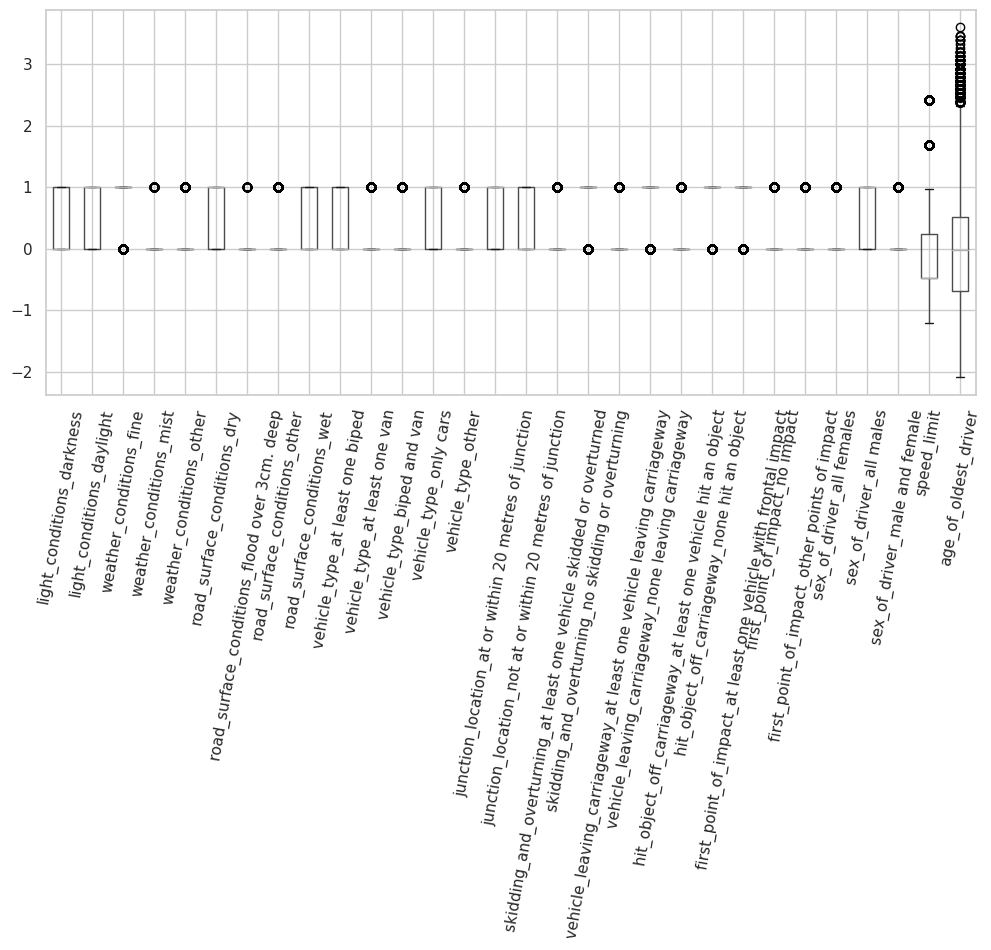

In [ ]:
fig=plt.figure(figsize=(12,5))
train_X_encoded_scaled.boxplot()
_=plt.xticks(rotation=80)

In [ ]:
train_X_encoded_scaled

,light_conditions_darkness,light_conditions_daylight,weather_conditions_fine,weather_conditions_mist,weather_conditions_other,road_surface_conditions_dry,road_surface_conditions_flood over 3cm. deep,road_surface_conditions_other,road_surface_conditions_wet,vehicle_type_at least one biped,...,hit_object_off_carriageway_at least one vehicle hit an object,hit_object_off_carriageway_none hit an object,first_point_of_impact_at least one vehicle with frontal impact,first_point_of_impact_no impact,first_point_of_impact_other points of impact,sex_of_driver_all females,sex_of_driver_all males,sex_of_driver_male and female,speed_limit,age_of_oldest_driver
0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.480025,-1.221592
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.695960,0.855020
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.480025,0.185146
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.480025,-0.015817
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.480025,-0.149792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23729,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.480025,-0.015817
23730,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.480025,-0.015817
23731,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.245303,-1.757491
23732,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.245303,0.988995


# 13. Dimentionality reduction using PCA

In [ ]:
comp_num_lst = range(2,30)
print(list(comp_num_lst))

var_exp_lst = []

for comp_num in comp_num_lst:
    pca = PCA(n_components=comp_num)
    pca = pca.fit(train_X_encoded_scaled)
    var_exp_lst.append(np.sum(pca.explained_variance_ratio_))
print(var_exp_lst)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
[0.3858742313154283, 0.48980289249895953, 0.5653579907271691, 0.6351377085158089, 0.7003916857030804, 0.7608484640147094, 0.8133228310771193, 0.8605738084478787, 0.8948140720573463, 0.9217958504190794, 0.9451279922584274, 0.9656711585737379, 0.9763693097509435, 0.9861894661176366, 0.9931305043480643, 0.9960350661281642, 0.9986559019777577, 0.9996013918892235, 1.0000000000000004, 1.0, 1.0000000000000004, 1.0000000000000004, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


Explained Variances: {2: 0.386, 3: 0.49, 4: 0.565, 5: 0.635, 6: 0.7, 7: 0.761, 8: 0.813, 9: 0.861, 10: 0.895, 11: 0.922, 12: 0.945, 13: 0.966, 14: 0.976, 15: 0.986, 16: 0.993, 17: 0.996, 18: 0.999, 19: 1.0, 20: 1.0, 21: 1.0, 22: 1.0, 23: 1.0, 24: 1.0, 25: 1.0, 26: 1.0, 27: 1.0, 28: 1.0, 29: 1.0}



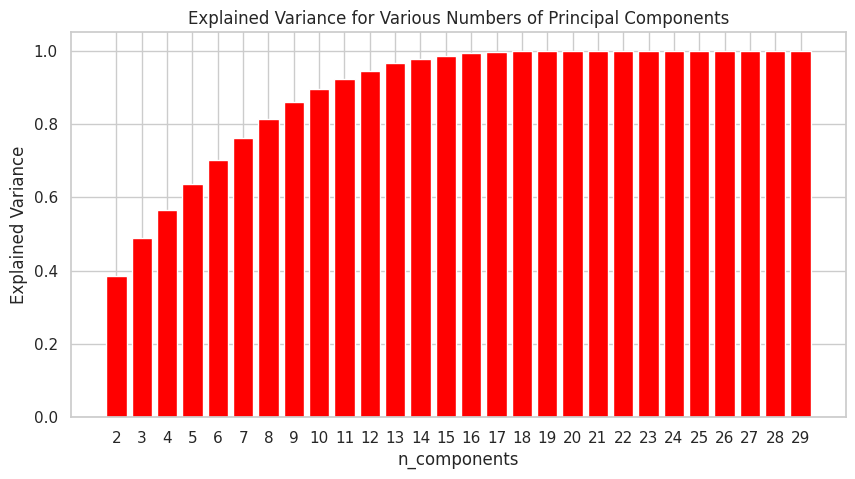

In [ ]:
ind = [i for i in range(len(comp_num_lst))]

fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(111)
_ = ax1.set_xticks(ind)
_ = ax1.set_xticklabels(comp_num_lst)
_ = ax1.bar(ind, var_exp_lst, width=0.8, color='red')
_ = ax1.set_title('Explained Variance for Various Numbers of Principal Components')
_ = ax1.set_xlabel('n_components')
_ = ax1.set_ylabel('Explained Variance')

print('Explained Variances: {}'.format(dict(zip(comp_num_lst, [np.around(t,3) for t in var_exp_lst]))))
print()
plt.show()

**To explain at least 90% (0.9) of variance we need at least 11 components.**

In [ ]:
pca90 = PCA(n_components=0.9)
reducedtrain = pca90.fit_transform(train_X_encoded_scaled)
var_exp_lst = []
var_exp_lst.append(np.sum(pca90.explained_variance_ratio_))
var_exp_lst

[0.9217958504190789]

In [ ]:
reducedtrain.shape

(23734, 11)

In [ ]:
pca90.explained_variance_ratio_

array([0.20792941, 0.17794482, 0.10392866, 0.0755551 , 0.06977972,
       0.06525398, 0.06045678, 0.05247437, 0.04725098, 0.03424026,
       0.02698178])

In [ ]:
reducedval=pca90.transform(val_X_encoded_scaled)
reducedtest=pca90.transform(test_X_encoded_scaled)

In [ ]:
reducedval.shape

(2638, 11)

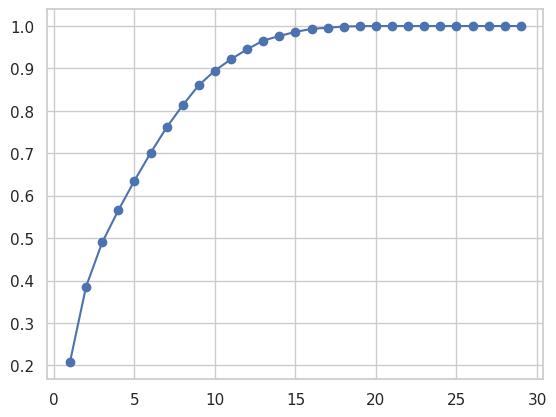

In [ ]:
plt.plot(np.arange(1,30), np.cumsum(pca.explained_variance_ratio_), '-o')

In [ ]:
pca_viz = PCA(n_components=30)
pca_viz_transform = pca_viz.fit_transform(train_X_encoded_scaled)

MultiIndex([(2,),
            (1,),
            (0,)],
           names=['accident_severity'])


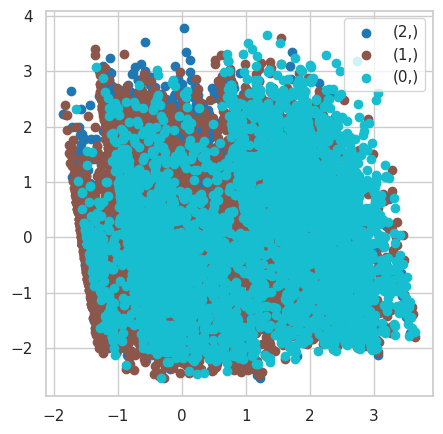

In [ ]:
classes_ = pd.DataFrame(train_y_without_nan_encoded, columns = ['accident_severity']).value_counts().index
print(classes_)

colors = cm.get_cmap("tab10")(np.linspace(0,1,len(classes_)))

plt.figure(figsize=(5,5))
for target_class,color in zip(classes_, colors):

    plt.scatter(pca_viz_transform[train_y_without_nan_encoded==target_class,0],
                pca_viz_transform[train_y_without_nan_encoded==target_class,1],
                label=target_class,
                color=color)
plt.legend()



---



# 14. Evaluating multiple traditional machine learning models

In [ ]:
def model_train(clf_, x_train, y_train, x_test, y_test, parameters):
  clf_search = RandomizedSearchCV(clf_, parameters, scoring= "balanced_accuracy", cv= 5)
  _ =clf_search.fit(x_train, y_train)
  best_clf = clf_search.best_estimator_
  y_pred = best_clf.predict(x_test)

  print("Optimal hyperparameters: ", best_clf)
  print(classification_report(y_test, y_pred, target_names = road_accidents_df_cleaned['accident_severity'].value_counts().index))
  print(f'\n Balanced accuracy is {balanced_accuracy_score(y_test, y_pred) :.2%}')

  con_mat = ConfusionMatrixDisplay.from_estimator(best_clf, x_test, y_test, display_labels= road_accidents_df_cleaned['accident_severity'].value_counts().index)
  plt.grid(False)

  return con_mat, best_clf

## 14.1 Logistics regression

In [ ]:
hyperparameter_space_lg = {'penalty': ['l1','l2','elastincnet'],'class_weight': ['balanced', None],'max_iter': [100,110]}

Optimal hyperparameters:  LogisticRegression(class_weight='balanced')
              precision    recall  f1-score   support

      Slight       0.58      0.82      0.68       534
     Serious       0.81      0.70      0.75      1007
       Fatal       0.82      0.75      0.78      1097

    accuracy                           0.75      2638
   macro avg       0.74      0.76      0.74      2638
weighted avg       0.77      0.75      0.75      2638


 Balanced accuracy is 75.78%


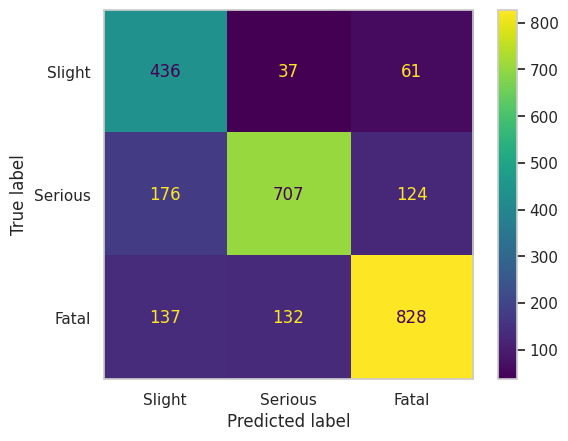

In [ ]:
con_mat_lg, best_clf_lg = model_train(LogisticRegression(), reducedtrain, train_y_without_nan_encoded, \
                                reducedval, val_y_without_nan_encoded, hyperparameter_space_lg)

## 14.2 Random forest

In [ ]:
hyperparameter_space_rf = {'criterion': ['entropy','gini'],'max_depth': [None,4,5,6], \
                        'max_features': ['auto','sqrt', None]}

Optimal hyperparameters:  RandomForestClassifier(criterion='entropy', max_depth=6, max_features=None)
              precision    recall  f1-score   support

      Slight       0.58      0.87      0.70       534
     Serious       0.79      0.70      0.74      1007
       Fatal       0.85      0.75      0.80      1097

    accuracy                           0.75      2638
   macro avg       0.74      0.77      0.75      2638
weighted avg       0.78      0.75      0.76      2638


 Balanced accuracy is 77.05%


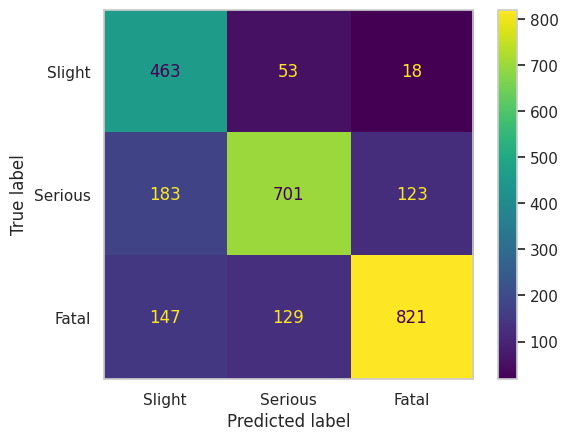

In [ ]:
con_mat, best_clf = model_train(RandomForestClassifier(), reducedtrain, train_y_without_nan_encoded, \
                                reducedval, val_y_without_nan_encoded, hyperparameter_space_rf)

## 14.3 Decision trees


In [ ]:
hyperparameter_space_dt = {'criterion': ['entropy', 'gini'],'max_depth': [None,4,5,6], \
                        'min_samples_leaf': [1,2,3],'splitter': ['best','random']}

Optimal hyperparameters:  DecisionTreeClassifier(criterion='entropy', max_depth=6)
              precision    recall  f1-score   support

      Slight       0.56      0.82      0.66       534
     Serious       0.80      0.69      0.74      1007
       Fatal       0.82      0.74      0.78      1097

    accuracy                           0.73      2638
   macro avg       0.72      0.75      0.73      2638
weighted avg       0.76      0.73      0.74      2638


 Balanced accuracy is 74.73%


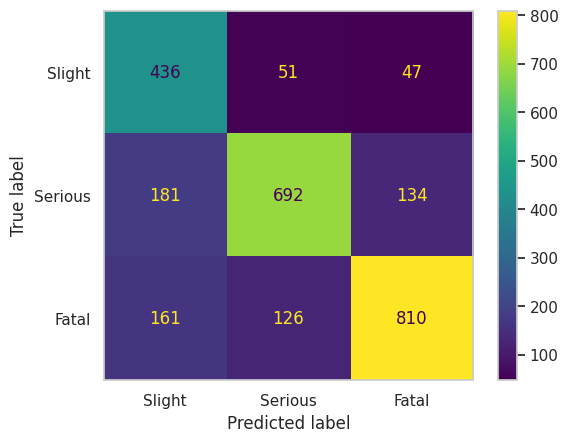

In [ ]:
con_mat_dt, best_clf_dt = model_train(DecisionTreeClassifier(), reducedtrain, train_y_without_nan_encoded, \
                                reducedval, val_y_without_nan_encoded, hyperparameter_space_dt)

## 14.4 Linear SVM classifier

In [ ]:
hyperparameter_space_svm = {'C': [1,2,3], 'class_weight': ['balanced',None],'penalty': ['l1','l2','elastincnet'] }

Optimal hyperparameters:  LinearSVC(C=3, class_weight='balanced')
              precision    recall  f1-score   support

      Slight       0.58      0.79      0.67       534
     Serious       0.80      0.69      0.74      1007
       Fatal       0.80      0.77      0.78      1097

    accuracy                           0.74      2638
   macro avg       0.73      0.75      0.73      2638
weighted avg       0.76      0.74      0.75      2638


 Balanced accuracy is 74.90%


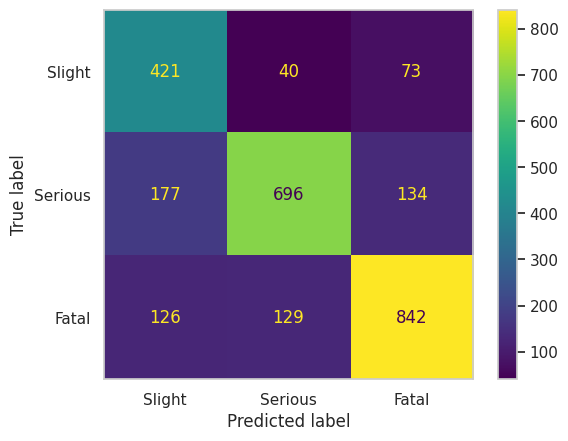

In [ ]:
con_mat_svm, best_clf_svm = model_train(LinearSVC(), reducedtrain, train_y_without_nan_encoded, \
                                reducedval, val_y_without_nan_encoded, hyperparameter_space_svm)

## 14.5 K-nearest neighbour

In [ ]:
hyperparameter_space_knn = {'n_neighbors': [3,5,7],'weights': ['uniform','distance'],'algorithm': ['auto', 'brute']}

Optimal hyperparameters:  KNeighborsClassifier(n_neighbors=7)
              precision    recall  f1-score   support

      Slight       0.60      0.72      0.65       534
     Serious       0.73      0.70      0.72      1007
       Fatal       0.80      0.75      0.78      1097

    accuracy                           0.73      2638
   macro avg       0.71      0.73      0.72      2638
weighted avg       0.74      0.73      0.73      2638


 Balanced accuracy is 72.57%


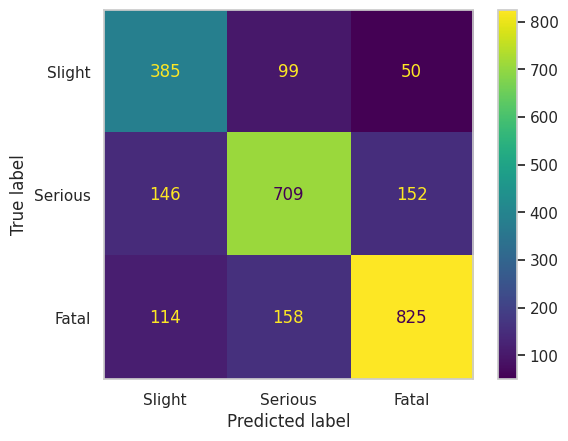

In [ ]:
con_mat_knn, best_clf_knn = model_train(KNeighborsClassifier(), reducedtrain, train_y_without_nan_encoded, \
                                reducedval, val_y_without_nan_encoded, hyperparameter_space_knn)



---



# 15. Neural Networks

## 15.1 Multi-Layer Perceptron

Feedforward Neural Networks (FNNs): FNNs, also known as Multi-Layer Perceptrons (MLPs), are the most basic type of neural network. They consist of an input layer, one or more hidden layers, and an output layer. FNNs are commonly used for multi-class classification problems.

In [ ]:
# Train and evaluate a multi-layer perceptron model
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, alpha=0.0001, random_state=42)
mlp.fit(reducedtrain, train_y_without_nan_encoded)
y_pred_mlp = mlp.predict(reducedtest)
print('Multi-layer Perceptron:')
print('Accuracy:', accuracy_score(test_y_without_nan_encoded, y_pred_mlp))
print('Precision:', precision_score(test_y_without_nan_encoded, y_pred_mlp, average='weighted'))
print('Recall:', recall_score(test_y_without_nan_encoded, y_pred_mlp, average='weighted'))
print('F1-Score:', f1_score(test_y_without_nan_encoded, y_pred_mlp, average='weighted'))
print('AUC-ROC:', roc_auc_score(test_y_without_nan_encoded, mlp.predict_proba(reducedtest), multi_class='ovr'))

Multi-layer Perceptron:
Accuracy: 0.7492323439099283
Precision: 0.7624478980095466
Recall: 0.7492323439099283
F1-Score: 0.7524504776003595
AUC-ROC: 0.8683905843076971


              precision    recall  f1-score   support

      Slight       0.60      0.77      0.67       594
     Serious       0.77      0.74      0.75      1118
       Fatal       0.84      0.75      0.79      1219

    accuracy                           0.75      2931
   macro avg       0.73      0.75      0.74      2931
weighted avg       0.76      0.75      0.75      2931

The balanced accuracy score is 75.24%



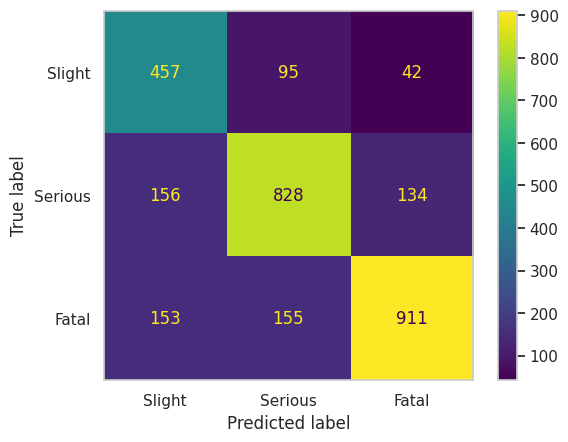

In [ ]:
print(classification_report(test_y_without_nan_encoded,y_pred_mlp,target_names= road_accidents_df_cleaned['accident_severity'].value_counts().index)) # this is to give the real categories, not their encoded numbers
print(f'The balanced accuracy score is {balanced_accuracy_score(test_y_without_nan_encoded,y_pred_mlp):.2%}\n')
cm = confusion_matrix(test_y_without_nan_encoded,y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= road_accidents_df_cleaned['accident_severity'].value_counts().index) # this is to give the real categories, not their encoded numbers
disp.plot()
plt.grid(False)
plt.show()

## 15.2 Deep Neural Network

### 15.2.1 Build model

In [ ]:
def create_model_single_hidden(n_hidden=20, num_of_input_features= reducedtrain.shape[1],dropout_rate =0.2):
  model = models.Sequential()
  model.add(layers.Dense(n_hidden, input_dim=num_of_input_features, activation='relu'))
  model.add(layers.Dropout(rate=dropout_rate))
  model.add(layers.Dense(n_hidden, activation='relu'))
  model.add(layers.Dense(3, activation='softmax')) #is it clear why here we use "sigmoid" and use "softmax" for multi-class problems?

  return model

### 15.2.2 Compile and training

In [ ]:
validation_data = (reducedval, val_y_without_nan_encoded)
l_rates = [0.00001, 0.00005 , 0.0001, 0.0005 ,0.001]
final_accuracies_train = []
final_accuracies_val = []
final_accuracies_test = []

In [ ]:
def model_compile_and_training(model, train_X, train_y,
                               optimizer_name = 'Adam', learning_rate= 0.001,
                               n_epochs= 100, batch_size=60,
                               validation_data= validation_data):

  optimizer = tf.keras.optimizers.Adam(learning_rate= l_rate)
  model.compile(optimizer=optimizer,loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])
  print(model.summary())

  # Training
  history = model.fit(train_X,
                    train_y,
                    epochs=n_epochs,
                    batch_size=batch_size,
                    validation_data= validation_data,
                    #verbose=0,
                    class_weight= class_weights,
                    )
  return model, history

In [ ]:
class_weights = class_weight.compute_class_weight(
    class_weight= "balanced",
    classes = np.unique(train_y_without_nan_encoded),
    y = train_y_without_nan_encoded)

class_weights = dict(zip(np.unique(train_y_without_nan_encoded), class_weights))
print(class_weights)

{0: 1.646479361775928, 1: 0.8736977728695012, 2: 0.8012288164202283}


In [ ]:
for i, l_rate in enumerate(l_rates):
    model = create_model_single_hidden()

    model, history = model_compile_and_training(model, reducedtrain, train_y_without_nan_encoded,
                               learning_rate= l_rate)

    final_accuracies_train.append(history.history['accuracy'][-1])
    final_accuracies_val.append(history.history['val_accuracy'][-1])

    test_probabilities = model.predict(reducedtest)
    test_predictions = np.argmax(test_probabilities, axis=1)
    final_accuracies_test.append(accuracy_score(test_y_without_nan_encoded,test_predictions))

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 20)                240       
                                                                 
 dropout (Dropout)           (None, 20)                0         
                                                                 
 dense_1 (Dense)             (None, 20)                420       
                                                                 
 dense_2 (Dense)             (None, 3)                 63        
                                                                 
Total params: 723
Trainable params: 723
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/100
396/396 [==============================] - 2s 3ms/step - loss: 1.3076 - accuracy: 0.3682 - val_loss: 1.1905 - val_accuracy: 0.3654
Epoch 2/100
396/396 [=====================

### 15.2.3 Model evaluation

              precision    recall  f1-score   support

      Slight       0.61      0.94      0.74       594
     Serious       0.84      0.73      0.78      1118
       Fatal       0.88      0.75      0.81      1219

    accuracy                           0.78      2931
   macro avg       0.78      0.81      0.78      2931
weighted avg       0.81      0.78      0.78      2931

The balanced accuracy score is 80.65%



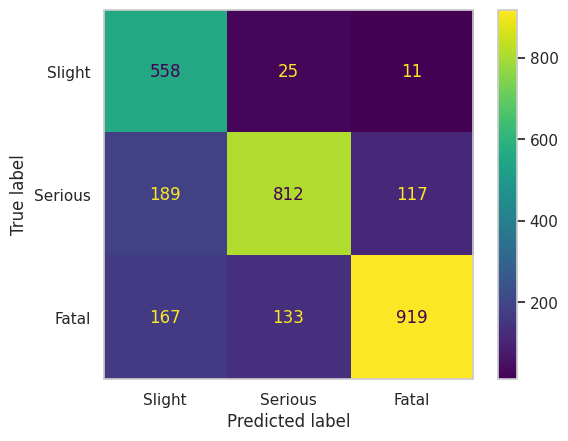

In [ ]:
print(classification_report(test_y_without_nan_encoded,test_predictions,target_names= road_accidents_df_cleaned['accident_severity'].value_counts().index)) # this is to give the real categories, not their encoded numbers
print(f'The balanced accuracy score is {balanced_accuracy_score(test_y_without_nan_encoded,test_predictions):.2%}\n')
cm = confusion_matrix(test_y_without_nan_encoded,test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= road_accidents_df_cleaned['accident_severity'].value_counts().index) # this is to give the real categories, not their encoded numbers
disp.plot()
plt.grid(False)
plt.show()

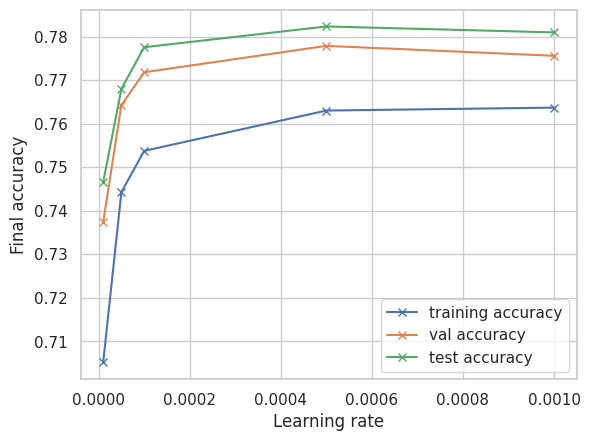

In [ ]:
plt.figure()
plt.plot(l_rates, final_accuracies_train, '-x', label='training accuracy')
plt.plot(l_rates, final_accuracies_val, '-x', label= 'val accuracy')
plt.plot(l_rates, final_accuracies_test, '-x', label= 'test accuracy')
plt.xlabel('Learning rate')
plt.ylabel('Final accuracy')
_ =plt.legend()

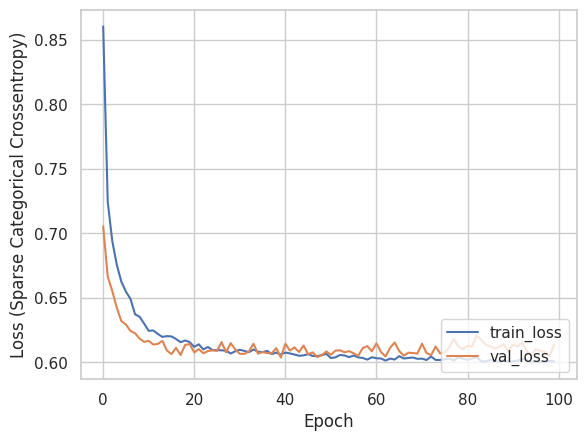

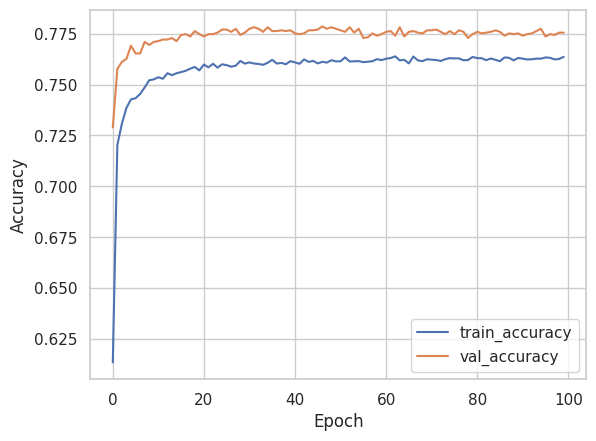

In [ ]:
# Plot training curves for both training and validation data
# loss per epoch
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Sparse Categorical Crossentropy)')
plt.legend(loc='lower right')

#accuracy per epoch
plt.figure()
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')